In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/DIP/archive (3).zip" -d /content/dataset

Archive:  /content/drive/MyDrive/DIP/archive (3).zip
  inflating: /content/dataset/Detect_solar_dust/Clean/Imgclean_0_0.jpg  
  inflating: /content/dataset/Detect_solar_dust/Clean/Imgclean_1000_0.jpg  
  inflating: /content/dataset/Detect_solar_dust/Clean/Imgclean_1001_0.jpg  
  inflating: /content/dataset/Detect_solar_dust/Clean/Imgclean_1002_0.jpg  
  inflating: /content/dataset/Detect_solar_dust/Clean/Imgclean_1003_0.jpg  
  inflating: /content/dataset/Detect_solar_dust/Clean/Imgclean_1004_0.jpg  
  inflating: /content/dataset/Detect_solar_dust/Clean/Imgclean_1005_0.jpg  
  inflating: /content/dataset/Detect_solar_dust/Clean/Imgclean_1006_0.jpg  
  inflating: /content/dataset/Detect_solar_dust/Clean/Imgclean_1007_0.jpg  
  inflating: /content/dataset/Detect_solar_dust/Clean/Imgclean_1008_0.jpg  
  inflating: /content/dataset/Detect_solar_dust/Clean/Imgclean_1009_0.jpg  
  inflating: /content/dataset/Detect_solar_dust/Clean/Imgclean_100_0.jpg  
  inflating: /content/dataset/Detect_so

In [ ]:
!ls /content/dataset

Detect_solar_dust


In [ ]:
!ls /content/dataset/Detect_solar_dust

Clean  Dusty


In [ ]:
!pip install --quiet gdown matplotlib seaborn pillow torchvision torch pandas scikit-learn

In [ ]:
# Cell 2 - imports
import os, glob, math, random, shutil
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import joblib

import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split


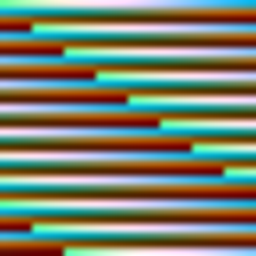

In [ ]:
# Cell 3 - helper: make an RGB mosaic from I-V arrays
import math

#saves png image from I-V data
def iv_to_rgb_mosaic(iv_df, out_path, grid_size=(32,32)):
    """
    iv_df: pandas DataFrame with columns ['voltage','current','power'] or a dict/array.
    grid_size: final mosaic resolution (height,width)
    Saves image at out_path (PNG).
    """
    # Accept multiple shapes: if iv_df is 1D array, interpret as volt or power
    if isinstance(iv_df, (np.ndarray, list)):
        arr = np.array(iv_df)
        # map arr to channels
        ch_r = arr.copy()
        ch_g = arr[::-1].copy()
        ch_b = np.abs(np.gradient(arr))
    else:
        # assume dataframe with columns
        if 'power' in iv_df.columns:
            ch_r = iv_df['voltage'].values
            ch_g = iv_df['current'].values
            ch_b = iv_df['power'].values
        else:
            # fallback: use first three numeric columns
            vals = iv_df.select_dtypes(include=[np.number]).values
            # pad/trim to 3 columns
            if vals.shape[1] >= 3:
                ch_r, ch_g, ch_b = vals[:,0], vals[:,1], vals[:,2]
            else:
                # repeat columns
                ch_r = vals[:,0]
                ch_g = vals[:,0]
                ch_b = vals[:,0]
    # normalize each channel to 0..1
    def norm(x):
        x = np.array(x, dtype=np.float32)
        if x.max() == x.min():
            return np.zeros_like(x)
        return (x - x.min()) / (x.max() - x.min())
    ch_r = norm(ch_r); ch_g = norm(ch_g); ch_b = norm(ch_b)

    # create grid by reshaping (tile if needed)
    total = grid_size[0]*grid_size[1]
    def make_grid(ch):
        # repeat or trim to length total
        if len(ch) >= total:
            v = ch[:total]
        else:
            repeats = math.ceil(total / len(ch))
            v = np.tile(ch, repeats)[:total]
        return v.reshape(grid_size)

    R = make_grid(ch_r)
    G = make_grid(ch_g)
    B = make_grid(ch_b)

    img = np.stack([R,G,B], axis=2)
    img = (img*255).astype(np.uint8)
    Image.fromarray(img).save(out_path)

# Example: synthetic demo
os.makedirs('mosaics/demo', exist_ok=True)
x = np.linspace(0,1,100)
sample_df = pd.DataFrame({'voltage':np.sin(2*np.pi*x*2)*(1-x)+2, 'current':(1-x)*0.5+0.1, 'power':(np.sin(2*np.pi*x*1)+1)*(1-x)})
iv_to_rgb_mosaic(sample_df, 'mosaics/demo/sample_mosaic.png', grid_size=(32,32))
Image.open('mosaics/demo/sample_mosaic.png').resize((256,256))


In [ ]:
# Cell 4 - batch convert iv CSVs  into mosaic images in a folder
def convert_iv_folder(iv_folder, out_folder, grid_size=(32,32), csv_ext='csv'):
    """
    Assumes each file in iv_folder is a CSV representing one I-V sample.
    Saves mosaics to out_folder maintaining same base name.
    """
    os.makedirs(out_folder, exist_ok=True)
    files = glob.glob(os.path.join(iv_folder, f"*.{csv_ext}"))
    for f in tqdm(files):
        try:
            df = pd.read_csv(f)
            outp = os.path.join(out_folder, os.path.splitext(os.path.basename(f))[0]+'.png')
            iv_to_rgb_mosaic(df, outp, grid_size)
        except Exception as e:
            print("skip", f, e)

# Example usage:
# convert_iv_folder('/content/drive/MyDrive/IV_csvs', '/content/mosaics/iv_mosaics', grid_size=(32,32))


In [ ]:
# Cell 5 - dataset class for mosaics and feature extraction
class MosaicDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        p = self.image_paths[idx]
        img = Image.open(p).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = self.labels[idx]
        return img, label

# transforms
feat_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# load model
device = "cuda" if torch.cuda.is_available() else "cpu"
resnet = models.resnet50(pretrained=True)
# remove classifier
modules = list(resnet.children())[:-1]  # remove last fc
feature_extractor = nn.Sequential(*modules).to(device)
feature_extractor.eval()

def extract_features(image_paths, batch_size=32):
    ds = MosaicDataset(image_paths, [0]*len(image_paths), transform=feat_transform)
    dl = DataLoader(ds, batch_size=batch_size, shuffle=False)
    feats = []
    with torch.no_grad():
        for imgs, _ in dl:
            imgs = imgs.to(device)
            out = feature_extractor(imgs)  # shape [B,2048,1,1]
            out = out.view(out.size(0), -1).cpu().numpy()
            feats.append(out)
    feats = np.vstack(feats)
    return feats


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 124MB/s]


In [ ]:
#creating augmented dataset
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
import os
import numpy as np
import shutil

# Paths
augmented_dir = "/content/augmented_dataset"
os.makedirs(augmented_dir, exist_ok=True)

# Create subfolders for Clean & Dusty
for cls in ["Clean", "Dusty"]:
    os.makedirs(os.path.join(augmented_dir, cls), exist_ok=True)

# Augmentation generator
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

def augment_images(src_folder, dst_folder, n_aug=3):
    for img_name in os.listdir(src_folder):
        img_path = os.path.join(src_folder, img_name)
        img = load_img(img_path, target_size=(224,224))  # resize to ResNet input
        x = img_to_array(img)
        x = np.expand_dims(x, axis=0)

        # Save original
        shutil.copy(img_path, os.path.join(dst_folder, img_name))

        # Generate augmented versions
        i = 0
        for batch in datagen.flow(x, batch_size=1, save_to_dir=dst_folder,
                                  save_prefix="aug", save_format="jpg"):
            i += 1
            if i >= n_aug:
                break

# Apply augmentation to both classes
base_dataset = "/content/dataset/Detect_solar_dust"
augment_images(os.path.join(base_dataset, "Clean"), os.path.join(augmented_dir, "Clean"))
augment_images(os.path.join(base_dataset, "Dusty"), os.path.join(augmented_dir, "Dusty"))

print("Augmentation completed! New dataset is in:", augmented_dir)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Augmentation completed! New dataset is in: /content/augmented_dataset


In [ ]:
# Use augmented dataset to train random forest to distinguish btw clean and dusty
base_mosaic_folder = "/content/augmented_dataset"

# auto-gather image paths + labels
image_paths = []
labels = []
for state in os.listdir(base_mosaic_folder):
    sdir = os.path.join(base_mosaic_folder, state)
    if not os.path.isdir(sdir):
        continue
    for ext in ("*.jpg", "*.jpeg", "*.png"):
        for imgf in glob.glob(os.path.join(sdir, ext)):
            image_paths.append(imgf)
            labels.append(state)

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(labels)
print("Classes:", list(le.classes_), " Total images:", len(image_paths))

# Train-test split
from sklearn.model_selection import train_test_split
X_train_paths, X_test_paths, y_train, y_test = train_test_split(
    image_paths, y, test_size=0.2, stratify=y, random_state=42
)

# Extract features
X_train_feats = extract_features(X_train_paths, batch_size=16)
X_test_feats  = extract_features(X_test_paths, batch_size=16)
print("Features shape:", X_train_feats.shape)

# Train Random Forest (tuned with more trees)
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=400, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train_feats, y_train)

# Evaluate
from sklearn.metrics import classification_report, accuracy_score
y_pred = rf.predict(X_test_feats)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))


Classes: [np.str_('Clean'), np.str_('Dusty')]  Total images: 8946


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Features shape: (7156, 2048)
Accuracy: 0.823463687150838
              precision    recall  f1-score   support

       Clean       0.80      0.92      0.86      1020
       Dusty       0.86      0.70      0.77       770

    accuracy                           0.82      1790
   macro avg       0.83      0.81      0.81      1790
weighted avg       0.83      0.82      0.82      1790



In [ ]:

0# ✅ Save trained model + label encoder (so prediction can load them later)
joblib.dump(rf, "/content/cnn_rf_primary.joblib")
joblib.dump(le, "/content/label_encoder.joblib")


['/content/label_encoder.joblib']

In [ ]:
base_mosaic_folder = "/content/augmented_dataset"


In [ ]:
# Cell 7 - train secondary model for severity like tells how dusty it is
# Let's assume mosaics/dust/ folder contains dust images and a CSV 'dust_severity.csv' linking filename->severity
dust_dir = os.path.join(base_mosaic_folder, 'dust')  # change name if label differs
# If you have CSV:
# df_sev = pd.read_csv('/content/mosaics/dust/dust_severity.csv')  # columns: filename,severity
# image_paths_sev = [os.path.join(dust_dir, f) for f in df_sev['filename']]
# y_sev = df_sev['severity'].map({'mild':0,'moderate':1,'severe':2}).values

# Fallback: if not available, skip training
if os.path.isdir(dust_dir):
    # gather all dust images and try to load severity from filename if encoded (e.g., img_severe_01.png)
    image_paths_sev = glob.glob(os.path.join(dust_dir, '*.png'))
    # For demo, generate random severity if real labels not available (replace this with real labels)
    y_sev = np.random.choice([0,1,2], size=len(image_paths_sev))
    if len(image_paths_sev) >= 10:
        X_tr_p, X_te_p, y_tr_s, y_te_s = train_test_split(image_paths_sev, y_sev, test_size=0.2, stratify=y_sev, random_state=42)
        X_tr_feats = extract_features(X_tr_p)
        X_te_feats = extract_features(X_te_p)
        rf_sev = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
        rf_sev.fit(X_tr_feats, y_tr_s)
        y_pred_sev = rf_sev.predict(X_te_feats)
        print("Severity classification report:")
        print(classification_report(y_te_s, y_pred_sev))
        joblib.dump(rf_sev, "cnn_rf_severity.joblib")
    else:
        print("Not enough dust samples to train severity model; provide labeled severity data.")
else:
    print("No dust folder found for severity training.")


No dust folder found for severity training.


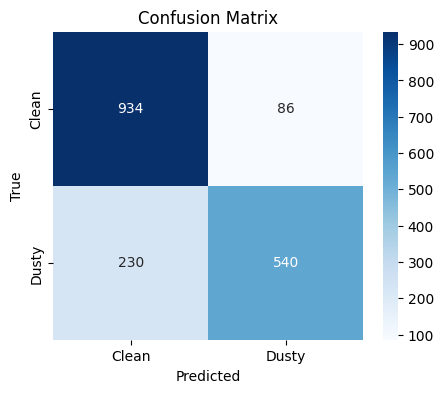

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
# testing model on 1 image
def predict_image(img_path, model, feature_extractor, label_encoder):
    img = Image.open(img_path).convert("RGB")
    img_t = feat_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        feat = feature_extractor(img_t).view(1, -1).cpu().numpy()

    pred = model.predict(feat)[0]
    prob = model.predict_proba(feat)[0][pred]

    return label_encoder.inverse_transform([pred])[0], prob


# 🔹 Example usage with random image (from Clean or Dusty)
import os, random

dataset_dir = "/content/dataset/Detect_solar_dust/"
folders = ["Clean", "Dusty"]

# Pick a random folder (Clean or Dusty)
chosen_folder = random.choice(folders)
folder_path = os.path.join(dataset_dir, chosen_folder)

# Pick a random image from that folder
all_images = [f for f in os.listdir(folder_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
test_image = random.choice(all_images)
img_path = os.path.join(folder_path, test_image)

# Run prediction
label, conf = predict_image(img_path, rf, feature_extractor, le)
print(f"Testing on: {img_path}")
print(f"Prediction: {label} (confidence {conf:.2f})")



Testing on: /content/dataset/Detect_solar_dust/Clean/Imgclean_1407_0.jpg
Prediction: Clean (confidence 0.73)


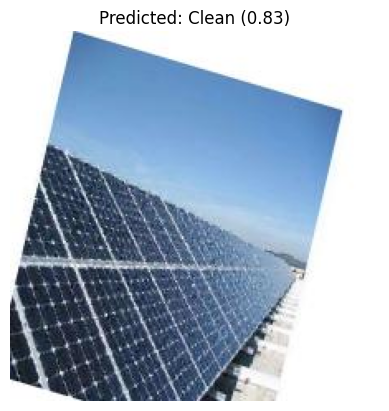

Image path: /content/augmented_dataset/Clean/aug_0_8311.jpg


In [ ]:
#visually test model on random image
import random

def test_random_image(image_paths, model, feature_extractor, label_encoder):
    # pick a random image from test set
    img_path = random.choice(image_paths)

    # predict
    label, conf = predict_image(img_path, model, feature_extractor, label_encoder)

    # show
    plt.imshow(Image.open(img_path))
    plt.axis("off")
    plt.title(f"Predicted: {label} ({conf:.2f})")
    plt.show()

    print("Image path:", img_path)

# Run it a few times
for _ in range(1):
    test_random_image(X_test_paths, rf, feature_extractor, le)


In [ ]:
# Train severity model (only on Dusty images with severity labels)
# Make sure you have a CSV: filename,severity
# severity = {mild:0, moderate:1, severe:2}

import pandas as pd

dust_dir = os.path.join(base_mosaic_folder, 'Dusty')  # your Dusty folder
csv_path = "/content/dust_severity.csv"  # <-- create this CSV with proper labels

if os.path.exists(csv_path):
    df_sev = pd.read_csv(csv_path)  # columns: filename,severity
    image_paths_sev = [os.path.join(dust_dir, f) for f in df_sev['filename']]
    y_sev = df_sev['severity'].map({'mild':0,'moderate':1,'severe':2}).values

    # split
    X_tr_p, X_te_p, y_tr_s, y_te_s = train_test_split(
        image_paths_sev, y_sev, test_size=0.2, stratify=y_sev, random_state=42
    )

    # features
    X_tr_feats = extract_features(X_tr_p)
    X_te_feats = extract_features(X_te_p)

    # train
    rf_sev = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf_sev.fit(X_tr_feats, y_tr_s)

    y_pred_sev = rf_sev.predict(X_te_feats)
    print("Severity classification report:")
    print(classification_report(y_te_s, y_pred_sev))

    joblib.dump(rf_sev, "cnn_rf_severity.joblib")
else:
    print("⚠️ No severity labels found, skipping severity model.")


⚠️ No severity labels found, skipping severity model.


In [ ]:
def cleaning_decision(estimated_power_kw, baseline_power_kw, severity_label, cleaning_cost, revenue_per_kwh, horizon_hours=24):
    """
    Intelligent Cleaning Decision Function
    --------------------------------------
    Determines if cleaning a solar panel is economically justified.

    Parameters:
    estimated_power_kw : float - current power output of the panel (kW)
    baseline_power_kw  : float - expected clean output (kW)
    severity_label     : int   - dust severity (0: mild, 1: moderate, 2: severe)
    cleaning_cost      : float - cost to clean this panel (in currency)
    revenue_per_kwh    : float - revenue earned per kWh
    horizon_hours      : int   - hours of production considered for estimation
    """

    # Map severity to estimated loss percentage
    severity_to_loss = {0: 0.05, 1: 0.15, 2: 0.30}
    loss_pct = severity_to_loss.get(severity_label, 0.1)

    # Calculate expected gain in power and revenue
    expected_gain_kw = baseline_power_kw * loss_pct
    expected_gain_kwh = expected_gain_kw * horizon_hours
    expected_revenue = expected_gain_kwh * revenue_per_kwh

    # Cleaning decision
    decision = expected_revenue > cleaning_cost
    decision_text = "✅ Cleaning is recommended." if decision else "❌ Cleaning not recommended now."

    # Print results clearly
    print("------ Cleaning Decision Summary ------")
    print(f"Dust Severity Level      : {['Mild', 'Moderate', 'Severe'][severity_label]}")
    print(f"Estimated Power Loss     : {loss_pct * 100:.1f}%")
    print(f"Expected Energy Gain     : {expected_gain_kwh:.2f} kWh over {horizon_hours} hrs")
    print(f"Expected Revenue Gain    : ₹{expected_revenue:.2f}")
    print(f"Cleaning Cost            : ₹{cleaning_cost:.2f}")
    print("--------------------------------------")
    print(decision_text)
    print("--------------------------------------")

    # Return structured data (for further processing if needed)
    return {
        'loss_pct': loss_pct,
        'expected_gain_kwh': expected_gain_kwh,
        'expected_revenue': expected_revenue,
        'cleaning_cost': cleaning_cost,
        'clean_now': decision
    }


# 🌞 Example Run
cleaning_decision(
    estimated_power_kw=0.65,
    baseline_power_kw=1.0,
    severity_label=2,
    cleaning_cost=10.0,
    revenue_per_kwh=0.09
)



------ Cleaning Decision Summary ------
Dust Severity Level      : Severe
Estimated Power Loss     : 30.0%
Expected Energy Gain     : 7.20 kWh over 24 hrs
Expected Revenue Gain    : ₹0.65
Cleaning Cost            : ₹10.00
--------------------------------------
❌ Cleaning not recommended now.
--------------------------------------


{'loss_pct': 0.3,
 'expected_gain_kwh': 7.199999999999999,
 'expected_revenue': 0.6479999999999999,
 'cleaning_cost': 10.0,
 'clean_now': False}

In [ ]:
import math, random

def greedy_route(points, start=(0,0)):
    route = [start]
    remaining = points.copy()
    cur = start
    while remaining:
        nxt = min(remaining, key=lambda p: (p[0]-cur[0])**2 + (p[1]-cur[1])**2)
        route.append(nxt)
        remaining.remove(nxt)
        cur = nxt
    return route

# Demo: 5x5 grid farm, 8 dirty panels
grid_points = [(i,j) for i in range(5) for j in range(5)]
dirty = random.sample(grid_points, 8)
route = greedy_route(dirty, start=(0,0))
print("Visit order:", route)


Visit order: [(0, 0), (1, 0), (0, 1), (2, 2), (1, 3), (2, 4), (4, 3), (4, 2), (4, 0)]


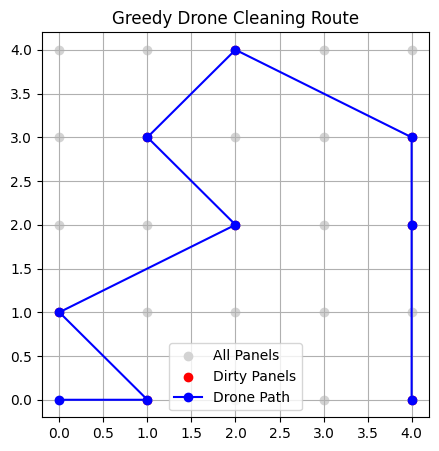

In [ ]:
import matplotlib.pyplot as plt

# Plot farm grid
plt.figure(figsize=(5,5))
plt.scatter(*zip(*grid_points), color='lightgray', label='All Panels')
plt.scatter(*zip(*dirty), color='red', label='Dirty Panels')
plt.plot(*zip(*route), '-o', color='blue', label='Drone Path')
plt.title("Greedy Drone Cleaning Route")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
def predict_sample(
    mosaic_path,
    rf_primary_path="/content/cnn_rf_primary.joblib",
    le_path="/content/label_encoder.joblib",
    rf_sev_path="/content/cnn_rf_severity.joblib"
):
    feats = extract_features([mosaic_path])

    rf = joblib.load(rf_primary_path)
    le = joblib.load(le_path)

    pred_idx = rf.predict(feats)[0]
    pred_state = le.inverse_transform([pred_idx])[0]

    out = {'state': pred_state}

    if pred_state.lower() in ['dust', 'dusty']:
        try:
            rf_sev = joblib.load(rf_sev_path)
            sev = rf_sev.predict(feats)[0]
            out['severity'] = int(sev)
        except:
            out['severity'] = None
    return out


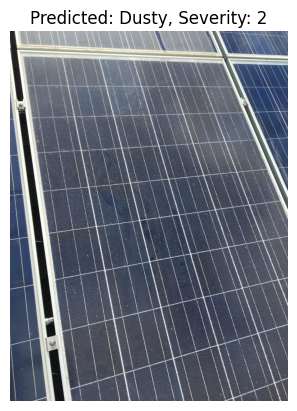

Actual folder: Dusty
Prediction result: {'state': np.str_('Dusty'), 'severity': np.int64(2), 'cleaning_decision': {'loss_pct': 0.3, 'expected_gain_kwh': 7.199999999999999, 'expected_revenue': 0.72, 'cleaning_cost': 10, 'clean_now': False}}
Image path: /content/dataset/Detect_solar_dust/Dusty/Imgdirty_707_1.jpg


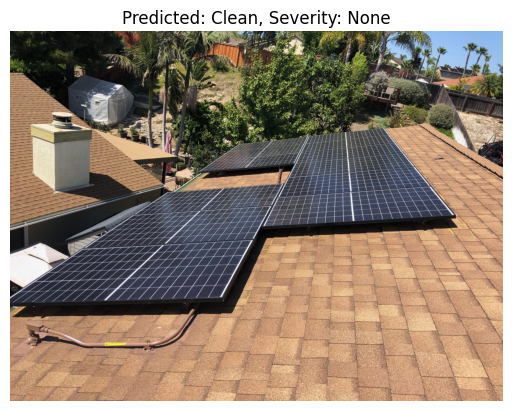

Actual folder: Clean
Prediction result: {'state': np.str_('Clean')}
Image path: /content/dataset/Detect_solar_dust/Clean/Imgclean_284_0.jpg


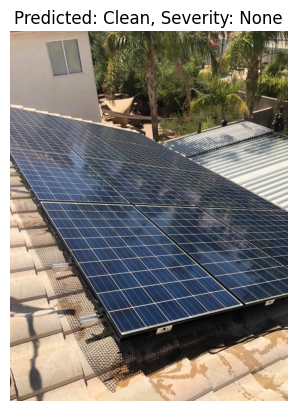

Actual folder: Clean
Prediction result: {'state': np.str_('Clean')}
Image path: /content/dataset/Detect_solar_dust/Clean/Imgclean_463_0.jpg


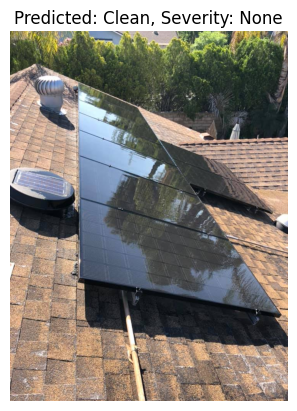

Actual folder: Clean
Prediction result: {'state': np.str_('Clean')}
Image path: /content/dataset/Detect_solar_dust/Clean/Imgclean_713_0.jpg


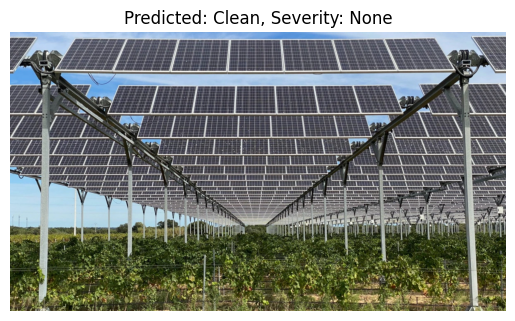

Actual folder: Clean
Prediction result: {'state': np.str_('Clean')}
Image path: /content/dataset/Detect_solar_dust/Clean/Imgclean_334_0.jpg


In [ ]:
import random

def test_random_from_dataset(base_folder="/content/dataset/Detect_solar_dust"):
    # Pick random folder (Clean or Dusty)
    classes = ["Clean", "Dusty"]
    chosen_class = random.choice(classes)

    # Pick random image from that folder
    img_folder = os.path.join(base_folder, chosen_class)
    imgs = glob.glob(os.path.join(img_folder, "*"))
    if not imgs:
        print(f"No images found in {img_folder}")
        return

    img_path = random.choice(imgs)

    # Run prediction
    result = predict_sample(img_path)

    # Show image + result
    plt.imshow(Image.open(img_path))
    plt.axis("off")
    plt.title(f"Predicted: {result['state']}, Severity: {result.get('severity')}")
    plt.show()

    print("Actual folder:", chosen_class)
    print("Prediction result:", result)
    print("Image path:", img_path)

# Run a few random tests
for _ in range(5):
    test_random_from_dataset()


In [ ]:
def evaluate_full_testset(test_paths, test_labels):
    feats = extract_features(test_paths)
    rf = joblib.load("cnn_rf_primary.joblib")
    le = joblib.load("label_encoder.joblib")
    preds = rf.predict(feats)
    print("Full Test Evaluation:")
    print(classification_report(test_labels, preds, target_names=le.classes_))

# Run it
evaluate_full_testset(X_test_paths, y_test)


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Full Test Evaluation:
              precision    recall  f1-score   support

       Clean       0.80      0.92      0.86      1020
       Dusty       0.86      0.70      0.77       770

    accuracy                           0.82      1790
   macro avg       0.83      0.81      0.81      1790
weighted avg       0.83      0.82      0.82      1790



In [ ]:
# Step 1: Train Severity Model (Dusty -> Mild / Moderate / Severe)

# Create a folder for Dusty samples (already exists in dataset)
dusty_paths = [p for p, l in zip(image_paths, labels) if l.lower() == "dusty"]

if len(dusty_paths) < 10:
    print("Not enough Dusty images for severity model.")
else:
    # ⚠️ Replace this with actual severity labels if you have them in a CSV
    # For now, we simulate (random labels: 0 = mild, 1 = moderate, 2 = severe)
    y_severity = np.random.choice([0,1,2], size=len(dusty_paths))

    X_tr_p, X_te_p, y_tr_s, y_te_s = train_test_split(
        dusty_paths, y_severity, test_size=0.2, stratify=y_severity, random_state=42
    )

    # Extract features
    X_tr_feats = extract_features(X_tr_p)
    X_te_feats = extract_features(X_te_p)

    # Train RF
    rf_sev = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf_sev.fit(X_tr_feats, y_tr_s)

    # Evaluate
    y_pred_sev = rf_sev.predict(X_te_feats)
    print("Severity classification report (simulated labels):")
    print(classification_report(y_te_s, y_pred_sev))

    # Save severity model
    joblib.dump(rf_sev, "cnn_rf_severity.joblib")


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Severity classification report (simulated labels):
              precision    recall  f1-score   support

           0       0.34      0.36      0.35       260
           1       0.32      0.31      0.31       255
           2       0.32      0.30      0.31       255

    accuracy                           0.32       770
   macro avg       0.32      0.32      0.32       770
weighted avg       0.32      0.32      0.32       770



In [ ]:
# Step 3: Route Optimization
def greedy_route(points, start=(0,0)):
    route = [start]
    remaining = points.copy()
    cur = start
    while remaining:
        nxt = min(remaining, key=lambda p: (p[0]-cur[0])**2 + (p[1]-cur[1])**2)
        route.append(nxt)
        remaining.remove(nxt)
        cur = nxt
    return route

# Demo: 5x5 solar farm, 8 random dirty panels
grid_points = [(i,j) for i in range(5) for j in range(5)]
dirty_panels = random.sample(grid_points, 8)
route = greedy_route(dirty_panels, start=(0,0))

print("Dirty panels:", dirty_panels)
print("Visit order (optimized):", route)


Dirty panels: [(2, 1), (2, 0), (0, 1), (1, 0), (2, 4), (1, 4), (4, 4), (0, 4)]
Visit order (optimized): [(0, 0), (0, 1), (1, 0), (2, 0), (2, 1), (2, 4), (1, 4), (0, 4), (4, 4)]


In [ ]:
# Step 4: End-to-End Prediction Pipeline
def predict_sample(mosaic_path):
    feats = extract_features([mosaic_path])

    # Load primary model
    rf = joblib.load("cnn_rf_primary.joblib")
    le = joblib.load("label_encoder.joblib")
    pred_idx = rf.predict(feats)[0]
    pred_state = le.inverse_transform([pred_idx])[0]

    result = {"state": pred_state}

    if pred_state.lower() == "dusty":
        try:
            rf_sev = joblib.load("cnn_rf_severity.joblib")
            sev = rf_sev.predict(feats)[0]
            result["severity"] = sev
            decision = cleaning_decision(
                estimated_power_kw=0.7,
                baseline_power_kw=1.0,
                severity_label=sev,
                cleaning_cost=10,
                revenue_per_kwh=0.1
            )
            result["cleaning_decision"] = decision
        except:
            result["severity"] = None

    return result

# Example run (pick one test image)
print(predict_sample(X_test_paths[0]))


{'state': np.str_('Clean')}


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = rf.predict(X_test_feats)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.823463687150838
              precision    recall  f1-score   support

       Clean       0.80      0.92      0.86      1020
       Dusty       0.86      0.70      0.77       770

    accuracy                           0.82      1790
   macro avg       0.83      0.81      0.81      1790
weighted avg       0.83      0.82      0.82      1790



In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Simulated severity prediction (replace later with model)
severity = np.random.choice([0, 1, 2])  # 0-mild, 1-moderate, 2-severe
label = ["Mild", "Moderate", "Severe"][severity]
print(f"🧠 Predicted Dust Severity: {label}")

# Simple cleaning decision
loss = [0.05, 0.15, 0.30][severity]
cost = [3, 7.5, 15][severity]
gain = 1.0 * loss * 24 * 0.09  # baseline*loss*hours*revenue
print(f"Expected gain: ₹{gain:.2f} | Cleaning cost: ₹{cost}")

if gain > cost:
    print("✅ Clean now")
else:
    print("❌ No cleaning needed yet")


🧠 Predicted Dust Severity: Severe
Expected gain: ₹0.65 | Cleaning cost: ₹15
❌ No cleaning needed yet
